In [41]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold 
import time
from sklearn.model_selection import cross_val_score
import optuna

In [11]:
# Load the Excel file using pandas
df = pd.read_excel('G:/OPC-mortar/Database.xlsx')

# Display the dataframe
df = df.drop(["ID"], axis = 1)
df

,LOI (%),Al2O3 (%),Fe2O3 (%),SO3 (%),Na2O (%),C3S,C2S,C3A,Blaine (m2/kg),Setting int (min),Setting final (min),28-days CS (MPa)
0,1.09,5.26,4.00,2.29,0.33,46.7798,24.911931,7.17100,331.0,167.0,236.0,50.6
1,0.98,5.18,3.98,2.36,0.32,48.9110,22.960606,6.99284,323.0,173.0,235.0,52.4
2,0.93,5.25,3.94,2.44,0.31,47.7372,24.907551,7.24602,331.0,174.0,240.0,54.8
3,0.98,5.18,4.02,2.47,0.32,47.1548,24.485681,6.92516,319.0,165.0,219.0,50.6
4,0.91,5.12,4.06,2.42,0.31,49.0790,22.661734,6.69848,331.0,166.0,220.0,52.5
...,...,...,...,...,...,...,...,...,...,...,...,...
308,2.30,0.48,2.78,3.66,4.90,11.1264,6.799600,19.17235,336.0,170.0,120.0,26.8
309,2.26,0.55,2.76,3.68,4.88,11.1872,6.712800,19.62595,335.0,160.0,117.0,27.7
310,2.30,0.54,2.74,3.68,4.90,11.1872,6.765800,20.14935,334.0,160.0,120.0,26.5
311,2.28,0.54,2.80,3.66,4.88,11.1264,6.746600,19.22420,330.0,160.0,122.0,27.1


In [13]:
# Checking for missing values
missing_values = df.isnull().sum()

# Displaying the number of missing values for each column (it will show the sum
# of the number of missing values rows for each column)
print("Missing values in each column:")
missing_values

Missing values in each column:


LOI (%)                0
Al2O3 (%)              0
Fe2O3 (%)              0
SO3 (%)                0
Na2O (%)               0
C3S                    0
C2S                    0
C3A                    0
Blaine (m2/kg)         0
Setting int (min)      0
Setting final (min)    0
28-days CS (MPa)       0
dtype: int64

In [15]:
# Remove all rows containing missing values
df_cleaned = df.dropna()

df[df.duplicated(keep=False)]

,LOI (%),Al2O3 (%),Fe2O3 (%),SO3 (%),Na2O (%),C3S,C2S,C3A,Blaine (m2/kg),Setting int (min),Setting final (min),28-days CS (MPa)


In [19]:
# for data scaling there are two methods: normalization and standardization
# in this case we used normalization method

#distinguishing between features and target
features = df_cleaned.drop(["28-days CS (MPa)"], axis = 1)
target_reg = df_cleaned["28-days CS (MPa)"]


#importing the library that has MinMaxScalar
from sklearn.preprocessing import MinMaxScaler

#Step1
scalar = MinMaxScaler()

#Step 2 and 3
scaled_feature = scalar.fit_transform(features)
scaled_feature = pd.DataFrame(scaled_feature, columns=features.columns)
scaled_feature

,LOI (%),Al2O3 (%),Fe2O3 (%),SO3 (%),Na2O (%),C3S,C2S,C3A,Blaine (m2/kg),Setting int (min),Setting final (min)
0,0.142336,0.928155,0.575221,0.384956,0.035565,0.731632,0.720426,0.180942,0.512605,0.618421,0.760736
1,0.102190,0.912621,0.566372,0.415929,0.033473,0.775292,0.643181,0.170391,0.445378,0.697368,0.754601
2,0.083942,0.926214,0.548673,0.451327,0.031381,0.751246,0.720252,0.185385,0.512605,0.710526,0.785276
3,0.102190,0.912621,0.584071,0.464602,0.033473,0.739315,0.703552,0.166383,0.411765,0.592105,0.656442
4,0.076642,0.900971,0.601770,0.442478,0.031381,0.778733,0.631350,0.152959,0.512605,0.605263,0.662577
...,...,...,...,...,...,...,...,...,...,...,...
308,0.583942,0.000000,0.035398,0.991150,0.991632,0.001246,0.003436,0.891686,0.554622,0.657895,0.049080
309,0.569343,0.013592,0.026549,1.000000,0.987448,0.002491,0.000000,0.918549,0.546218,0.526316,0.030675
310,0.583942,0.011650,0.017699,1.000000,0.991632,0.002491,0.002098,0.949546,0.537815,0.526316,0.049080
311,0.576642,0.011650,0.044248,0.991150,0.987448,0.001246,0.001338,0.894757,0.504202,0.526316,0.061350


In [25]:
# Set a random seed for reproducibility
RANDOM_SEED = 42
#np.random.seed(RANDOM_SEED)

# LR accross several runs

In [34]:
# Import LR model
from sklearn.linear_model import LinearRegression

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# divide the dataset into four groups: Train and test features and train and test target
# import the library that can split the dataset
from sklearn.model_selection import train_test_split


# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = LinearRegression()  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_lr = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_lr)
    mse = mean_squared_error(y_test_reg, y_test_pred_lr)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_lr))
    mae = mean_absolute_error(y_test_reg, y_test_pred_lr)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_lr)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Results over 5 runs:
MAE_mean: 2.3380
MAE_std: 0.2229
MSE_mean: 10.1782
MSE_std: 1.9873
RMSE_mean: 3.1745
RMSE_std: 0.3177
R2_mean: 0.7283
R2_std: 0.0359
MAPE_mean: 0.0530
MAPE_std: 0.0064


# KNN across several runs

In [37]:
# Import KNN model
from sklearn.neighbors import KNeighborsRegressor

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = KNeighborsRegressor(
        n_neighbors=6,
        metric='minkowski',
        p=2,
        weights='distance')  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_KNN = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_KNN)
    mse = mean_squared_error(y_test_reg, y_test_pred_KNN)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_KNN))
    mae = mean_absolute_error(y_test_reg, y_test_pred_KNN)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_KNN)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Results over 5 runs:
MAE_mean: 1.2141
MAE_std: 0.0369
MSE_mean: 2.4669
MSE_std: 0.1641
RMSE_mean: 1.5698
RMSE_std: 0.0523
R2_mean: 0.9327
R2_std: 0.0100
MAPE_mean: 0.0266
MAPE_std: 0.0006


In [51]:
# KNN optimization using Optuna and its time
from sklearn.neighbors import KNeighborsRegressor


def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 1, 31)
    weights = trial.suggest_categorical('weights', ["uniform", "distance"])
    p = trial.suggest_int('p', 1, 3)
    metric = trial.suggest_categorical('metric', ["minkowski"])
    
    model_opt_KNN = KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p, metric=metric)
    score = cross_val_score(model_opt_KNN, X_reg, y_reg, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error').mean()
    return score

# Record start time
start_time = time.time()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

# Record end time
end_time = time.time()

# Compute elapsed time in minutes
elapsed_minutes = (end_time - start_time) / 60
print(f"Optimization completed in {elapsed_minutes:.2f} minutes")
print("Best hyperparameters found:", study.best_params)

[I 2026-02-25 14:20:25,880] A new study created in memory with name: no-name-2a8cdd3b-0074-4e5b-bfe9-79c115a3a9ac
[I 2026-02-25 14:20:25,941] Trial 0 finished with value: -3.26571171091803 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 2, 'metric': 'minkowski'}. Best is trial 0 with value: -3.26571171091803.
[I 2026-02-25 14:20:26,059] Trial 1 finished with value: -4.162218722060869 and parameters: {'n_neighbors': 31, 'weights': 'uniform', 'p': 3, 'metric': 'minkowski'}. Best is trial 0 with value: -3.26571171091803.
[I 2026-02-25 14:20:26,122] Trial 2 finished with value: -2.979351040975029 and parameters: {'n_neighbors': 5, 'weights': 'uniform', 'p': 2, 'metric': 'minkowski'}. Best is trial 2 with value: -2.979351040975029.
[I 2026-02-25 14:20:26,212] Trial 3 finished with value: -3.6618419822772075 and parameters: {'n_neighbors': 28, 'weights': 'distance', 'p': 3, 'metric': 'minkowski'}. Best is trial 2 with value: -2.979351040975029.
[I 2026-02-25 14:20:26,297] Tria

Optimization completed in 0.05 minutes
Best hyperparameters found: {'n_neighbors': 4, 'weights': 'distance', 'p': 3, 'metric': 'minkowski'}


In [57]:
# KNN optimization using grid search and its time

# Define the parameter grid for KNN
param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2, 3],           # p=1: Manhattan, p=2: Euclidean, p=3: more general Minkowski
    'metric': ['minkowski']    # fixed
}

# Create the GridSearchCV object
grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=10,                      # same as your cross-validation folds
    scoring='neg_mean_absolute_error',
    n_jobs=-1                   # use all cores for parallel computation
)

# Record start time
start_time = time.time()

# Fit the grid search to your data
grid_search.fit(X_reg, y_reg)

# Record end time
end_time = time.time()

# Compute elapsed time in minutes
elapsed_minutes = (end_time - start_time) / 60
print(f"Grid search completed in {elapsed_minutes:.2f} minutes")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best MAE (negative): {grid_search.best_score_}")

Grid search completed in 0.08 minutes
Best parameters: {'metric': 'minkowski', 'n_neighbors': 6, 'p': 2, 'weights': 'distance'}
Best MAE (negative): -2.911981059312751


In [61]:
# KNN optimization in several runs
# Define the objective function (unchanged)
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 1, 31)
    weights = trial.suggest_categorical('weights', ["uniform", "distance"])
    p = trial.suggest_int('p', 1, 3)
    metric = trial.suggest_categorical('metric', ["minkowski"])
    
    model_opt_KNN = KNeighborsRegressor(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        metric=metric
    )
    
    score = cross_val_score(
        model_opt_KNN,
        X_reg, y_reg,
        n_jobs=-1,
        cv=10,
        scoring='neg_mean_absolute_error'
    ).mean()
    return score

# Number of independent runs
n_runs = 10
results = []

for run in range(n_runs):
    print(f"\n--- Run {run+1} ---")
    # Use a different random seed for each run
    sampler = optuna.samplers.TPESampler(seed=run)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Optionally track time
    start = time.time()
    study.optimize(objective, n_trials=40, show_progress_bar=False)
    elapsed = time.time() - start
    
    # Store best parameters and best score
    result = {
        'run': run,
        'best_score': study.best_value,
        'n_neighbors': study.best_params['n_neighbors'],
        'weights': study.best_params['weights'],
        'p': study.best_params['p'],
        'metric': study.best_params['metric'],
        'time_min': elapsed / 60
    }
    results.append(result)
    print(f"Best score: {study.best_value:.4f}, params: {study.best_params}")

# Convert to DataFrame for analysis
df_results = pd.DataFrame(results)
print("\n=== Summary of runs ===")
print(df_results)

# Compute summary statistics
summary = {}
# Numeric hyperparameters
summary['n_neighbors'] = {
    'mean': df_results['n_neighbors'].mean(),
    'std': df_results['n_neighbors'].std(),
    'min': df_results['n_neighbors'].min(),
    'max': df_results['n_neighbors'].max()
}
summary['p'] = {
    'mean': df_results['p'].mean(),
    'std': df_results['p'].std(),
    'min': df_results['p'].min(),
    'max': df_results['p'].max()
}
# Best score
summary['best_score'] = {
    'mean': df_results['best_score'].mean(),
    'std': df_results['best_score'].std(),
    'min': df_results['best_score'].min(),
    'max': df_results['best_score'].max()
}
# Categorical hyperparameter: frequency
weights_freq = df_results['weights'].value_counts()
summary['weights_freq'] = weights_freq.to_dict()

print("\n=== Stability Analysis ===")
for key, value in summary.items():
    print(f"{key}: {value}")

[I 2026-02-25 14:24:14,396] A new study created in memory with name: no-name-5c497d9f-468e-4a0c-9a93-9a683b8d1a38
[I 2026-02-25 14:24:14,474] Trial 0 finished with value: -3.573368118601267 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'p': 2, 'metric': 'minkowski'}. Best is trial 0 with value: -3.573368118601267.
[I 2026-02-25 14:24:14,535] Trial 1 finished with value: -3.3675636750251563 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'p': 3, 'metric': 'minkowski'}. Best is trial 1 with value: -3.3675636750251563.



--- Run 1 ---


[I 2026-02-25 14:24:14,631] Trial 2 finished with value: -3.670992049907394 and parameters: {'n_neighbors': 30, 'weights': 'distance', 'p': 2, 'metric': 'minkowski'}. Best is trial 1 with value: -3.3675636750251563.
[I 2026-02-25 14:24:14,765] Trial 3 finished with value: -3.7683134513788206 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'p': 1, 'metric': 'minkowski'}. Best is trial 1 with value: -3.3675636750251563.
[I 2026-02-25 14:24:14,852] Trial 4 finished with value: -3.1638164712453483 and parameters: {'n_neighbors': 1, 'weights': 'uniform', 'p': 3, 'metric': 'minkowski'}. Best is trial 4 with value: -3.1638164712453483.
[I 2026-02-25 14:24:14,951] Trial 5 finished with value: -4.162218722060869 and parameters: {'n_neighbors': 31, 'weights': 'uniform', 'p': 3, 'metric': 'minkowski'}. Best is trial 4 with value: -3.1638164712453483.
[I 2026-02-25 14:24:15,038] Trial 6 finished with value: -2.9612376107746057 and parameters: {'n_neighbors': 4, 'weights': 'uniform', 'p':

Best score: -2.9120, params: {'n_neighbors': 6, 'weights': 'distance', 'p': 2, 'metric': 'minkowski'}

--- Run 2 ---


[I 2026-02-25 14:24:18,462] Trial 2 finished with value: -3.300566153471114 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 3, 'metric': 'minkowski'}. Best is trial 1 with value: -2.919594548618734.
[I 2026-02-25 14:24:18,551] Trial 3 finished with value: -3.0748897636075454 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'p': 3, 'metric': 'minkowski'}. Best is trial 1 with value: -2.919594548618734.
[I 2026-02-25 14:24:18,620] Trial 4 finished with value: -3.546827215772813 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 1, 'metric': 'minkowski'}. Best is trial 1 with value: -2.919594548618734.
[I 2026-02-25 14:24:18,682] Trial 5 finished with value: -4.000638760804636 and parameters: {'n_neighbors': 25, 'weights': 'uniform', 'p': 3, 'metric': 'minkowski'}. Best is trial 1 with value: -2.919594548618734.
[I 2026-02-25 14:24:18,734] Trial 6 finished with value: -4.272157962785154 and parameters: {'n_neighbors': 28, 'weights': 'uniform', 'p': 1, 'm

...

Best score: -2.9338, params: {'n_neighbors': 7, 'weights': 'distance', 'p': 2, 'metric': 'minkowski'}

--- Run 9 ---


[I 2026-02-25 14:24:37,005] Trial 3 finished with value: -3.938013276041855 and parameters: {'n_neighbors': 24, 'weights': 'uniform', 'p': 2, 'metric': 'minkowski'}. Best is trial 1 with value: -2.9645081310211996.
[I 2026-02-25 14:24:37,055] Trial 4 finished with value: -3.3859326561939262 and parameters: {'n_neighbors': 9, 'weights': 'uniform', 'p': 1, 'metric': 'minkowski'}. Best is trial 1 with value: -2.9645081310211996.
[I 2026-02-25 14:24:37,105] Trial 5 finished with value: -3.2282975967437393 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'p': 1, 'metric': 'minkowski'}. Best is trial 1 with value: -2.9645081310211996.
[I 2026-02-25 14:24:37,167] Trial 6 finished with value: -2.981219417194937 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'p': 3, 'metric': 'minkowski'}. Best is trial 1 with value: -2.9645081310211996.
[I 2026-02-25 14:24:37,219] Trial 7 finished with value: -3.1883798742765777 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'p': 

Best score: -2.9479, params: {'n_neighbors': 4, 'weights': 'distance', 'p': 3, 'metric': 'minkowski'}

--- Run 10 ---


[I 2026-02-25 14:24:39,734] Trial 4 finished with value: -4.108781134214002 and parameters: {'n_neighbors': 28, 'weights': 'uniform', 'p': 3, 'metric': 'minkowski'}. Best is trial 2 with value: -2.9799112528369713.
[I 2026-02-25 14:24:39,783] Trial 5 finished with value: -3.023583246756794 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 2, 'metric': 'minkowski'}. Best is trial 2 with value: -2.9799112528369713.
[I 2026-02-25 14:24:39,841] Trial 6 finished with value: -3.7684720172993793 and parameters: {'n_neighbors': 30, 'weights': 'distance', 'p': 1, 'metric': 'minkowski'}. Best is trial 2 with value: -2.9799112528369713.
[I 2026-02-25 14:24:39,925] Trial 7 finished with value: -3.5544311047101274 and parameters: {'n_neighbors': 17, 'weights': 'uniform', 'p': 3, 'metric': 'minkowski'}. Best is trial 2 with value: -2.9799112528369713.
[I 2026-02-25 14:24:39,998] Trial 8 finished with value: -3.720795748874253 and parameters: {'n_neighbors': 31, 'weights': 'distance', '

Best score: -2.9612, params: {'n_neighbors': 4, 'weights': 'uniform', 'p': 3, 'metric': 'minkowski'}

=== Summary of runs ===
   run  best_score  n_neighbors   weights  p     metric  time_min
0    0   -2.911981            6  distance  2  minkowski  0.064088
1    1   -2.911981            6  distance  2  minkowski  0.048403
2    2   -2.911981            6  distance  2  minkowski  0.042281
3    3   -2.911981            6  distance  2  minkowski  0.045401
4    4   -2.933798            7  distance  2  minkowski  0.041626
5    5   -2.947939            4  distance  3  minkowski  0.044165
6    6   -2.947939            4  distance  3  minkowski  0.041460
7    7   -2.933798            7  distance  2  minkowski  0.045446
8    8   -2.947939            4  distance  3  minkowski  0.044755
9    9   -2.961238            4   uniform  3  minkowski  0.048454

=== Stability Analysis ===
n_neighbors: {'mean': 5.4, 'std': 1.2649110640673518, 'min': 4, 'max': 7}
p: {'mean': 2.4, 'std': 0.5163977794943223, 'm

# SVM across several runs

In [64]:
# Import SVM model
from sklearn.svm import SVR

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = SVR(
        C=7.1,
        kernel='poly',
        gamma ='scale')  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_svr = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_svr)
    mse = mean_squared_error(y_test_reg, y_test_pred_svr)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_svr))
    mae = mean_absolute_error(y_test_reg, y_test_pred_svr)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_svr)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Results over 5 runs:
MAE_mean: 1.3984
MAE_std: 0.0660
MSE_mean: 3.4314
MSE_std: 0.5347
RMSE_mean: 1.8468
RMSE_std: 0.1444
R2_mean: 0.9080
R2_std: 0.0096
MAPE_mean: 0.0314
MAPE_std: 0.0021


# DT across everal runs

In [67]:
# Import DT model
from sklearn.tree import DecisionTreeRegressor

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = DecisionTreeRegressor(
        criterion='absolute_error',
        max_depth=3,
        min_samples_leaf=5,
        min_samples_split=3)  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_dt0 = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_dt0)
    mse = mean_squared_error(y_test_reg, y_test_pred_dt0)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_dt0))
    mae = mean_absolute_error(y_test_reg, y_test_pred_dt0)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_dt0)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Results over 5 runs:
MAE_mean: 1.9000
MAE_std: 0.1427
MSE_mean: 8.2996
MSE_std: 3.1406
RMSE_mean: 2.8375
RMSE_std: 0.4981
R2_mean: 0.7765
R2_std: 0.0801
MAPE_mean: 0.0419
MAPE_std: 0.0032


# RF across several runs

In [70]:
# Import RF model
from sklearn.ensemble import RandomForestRegressor

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = RandomForestRegressor(
        max_depth=12,
        n_estimators=7)  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_rf0 = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_rf0)
    mse = mean_squared_error(y_test_reg, y_test_pred_rf0)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_rf0))
    mae = mean_absolute_error(y_test_reg, y_test_pred_rf0)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_rf0)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Results over 5 runs:
MAE_mean: 1.4805
MAE_std: 0.0969
MSE_mean: 4.0263
MSE_std: 0.9064
RMSE_mean: 1.9938
RMSE_std: 0.2257
R2_mean: 0.8911
R2_std: 0.0249
MAPE_mean: 0.0327
MAPE_std: 0.0023


# ET

In [106]:
# Import ET model 
from sklearn.ensemble import ExtraTreesRegressor

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = ExtraTreesRegressor(
        max_depth=12,
        n_estimators=7)  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_extra_trees = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_extra_trees)
    mse = mean_squared_error(y_test_reg, y_test_pred_extra_trees)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_extra_trees))
    mae = mean_absolute_error(y_test_reg, y_test_pred_extra_trees)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_extra_trees)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Results over 5 runs:
MAE_mean: 1.3187
MAE_std: 0.0697
MSE_mean: 3.1170
MSE_std: 0.4276
RMSE_mean: 1.7614
RMSE_std: 0.1203
R2_mean: 0.9152
R2_std: 0.0147
MAPE_mean: 0.0288
MAPE_std: 0.0017


# AdaBoost across several runs

In [115]:
# Import adaboost and DT models 
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor 

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(
            max_depth=9,
        ),
        #learning_rate=0.7,
        #n_estimators=12
        learning_rate=1.6320950399222907,
        n_estimators=74)  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_adaboost = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_adaboost)
    mse = mean_squared_error(y_test_reg, y_test_pred_adaboost)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_adaboost))
    mae = mean_absolute_error(y_test_reg, y_test_pred_adaboost)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_adaboost)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Results over 5 runs:
MAE_mean: 1.2502
MAE_std: 0.0435
MSE_mean: 2.7440
MSE_std: 0.2251
RMSE_mean: 1.6550
RMSE_std: 0.0699
R2_mean: 0.9252
R2_std: 0.0118
MAPE_mean: 0.0274
MAPE_std: 0.0010


# GBM

In [117]:
# Import GBM model
from sklearn.ensemble import GradientBoostingRegressor

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = GradientBoostingRegressor(
        learning_rate=0.6007468823390762,
        max_depth=2,
        n_estimators=71)  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_gbm = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_gbm)
    mse = mean_squared_error(y_test_reg, y_test_pred_gbm)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_gbm))
    mae = mean_absolute_error(y_test_reg, y_test_pred_gbm)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_gbm)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Results over 5 runs:
MAE_mean: 1.6380
MAE_std: 0.0943
MSE_mean: 4.5742
MSE_std: 0.5960
RMSE_mean: 2.1341
RMSE_std: 0.1416
R2_mean: 0.8764
R2_std: 0.0171
MAPE_mean: 0.0360
MAPE_std: 0.0021


# XGB across several runs

In [120]:
# Import XGB model
from xgboost import XGBRegressor

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = XGBRegressor(
        max_depth=2,
        n_estimators=120,
        reg_lambda= 0.25,
        gamma = 0.35,
        subsample=0.35,
        alpha = 0.75)  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_xgb0 = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_xgb0)
    mse = mean_squared_error(y_test_reg, y_test_pred_xgb0)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_xgb0))
    mae = mean_absolute_error(y_test_reg, y_test_pred_xgb0)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_xgb0)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Results over 5 runs:
MAE_mean: 1.6719
MAE_std: 0.1455
MSE_mean: 4.5506
MSE_std: 1.0519
RMSE_mean: 2.1194
RMSE_std: 0.2428
R2_mean: 0.8771
R2_std: 0.0277
MAPE_mean: 0.0369
MAPE_std: 0.0031


# LGBM across several runs

In [123]:
# Import your models 
from lightgbm import LGBMRegressor

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = LGBMRegressor(
        reg_lambda= 0.8,
        reg_alpha= 0.25,
        num_leaves= 114,
        n_estimators= 235,
        learning_rate= 0.35)  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_lgbm0 = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_lgbm0)
    mse = mean_squared_error(y_test_reg, y_test_pred_lgbm0)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_lgbm0))
    mae = mean_absolute_error(y_test_reg, y_test_pred_lgbm0)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_lgbm0)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 563
[LightGBM] [Info] Number of data points in the train set: 219, number of used features: 11
[LightGBM] [Info] Start training from score 45.754947
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

# CatBoost across several runs

In [126]:
# Import CatBoost model
from catboost import CatBoostRegressor

# Assume X, y are already defined
# List of random seeds
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

for seed in seeds:
    # Split data
    #for regression problem
    X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = seed)
    
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = CatBoostRegressor(random_seed=42)  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_cat_reg = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_cat_reg)
    mse = mean_squared_error(y_test_reg, y_test_pred_cat_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_cat_reg))
    mae = mean_absolute_error(y_test_reg, y_test_pred_cat_reg)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_cat_reg)


    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
    
    
}

print("Results over 5 runs:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Learning rate set to 0.032208
0:	learn: 6.1722472	total: 153ms	remaining: 2m 32s
1:	learn: 6.0715954	total: 161ms	remaining: 1m 20s
2:	learn: 5.9486323	total: 164ms	remaining: 54.5s
3:	learn: 5.8470177	total: 167ms	remaining: 41.7s
4:	learn: 5.7420665	total: 170ms	remaining: 33.8s
5:	learn: 5.6354826	total: 173ms	remaining: 28.7s
6:	learn: 5.5454835	total: 176ms	remaining: 25s
7:	learn: 5.4424494	total: 179ms	remaining: 22.2s
8:	learn: 5.3468544	total: 183ms	remaining: 20.2s
9:	learn: 5.2682909	total: 186ms	remaining: 18.4s
10:	learn: 5.1678085	total: 189ms	remaining: 17s
11:	learn: 5.0922825	total: 192ms	remaining: 15.8s
12:	learn: 5.0016902	total: 194ms	remaining: 14.7s
13:	learn: 4.9155302	total: 196ms	remaining: 13.8s
14:	learn: 4.8499427	total: 199ms	remaining: 13.1s
15:	learn: 4.7664814	total: 202ms	remaining: 12.4s
16:	learn: 4.6975353	total: 205ms	remaining: 11.9s
17:	learn: 4.6217058	total: 208ms	remaining: 11.3s
18:	learn: 4.5637643	total: 211ms	remaining: 10.9s
19:	learn: 4.

# ANN

In [85]:
# Import tensorflow and the necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner import GridSearch
from keras_tuner import RandomSearch
from sklearn.model_selection import train_test_split
import numpy as np
import random

# Set Random Seed
tf.random.set_seed(RANDOM_SEED)

In [89]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# TensorFlow / Keras imports for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

# Set global random seed for reproducibility
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Assume X_reg, y_reg are already defined
X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# List of random seeds for different splits
seeds = [11, 42, 123, 789, 101112]

# Store results
results = {
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

# Function to create the ANN with optimal hyperparameters
def create_ann_model(input_dim):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    
    # First layer (416 units, ReLU)
    model.add(Dense(units=416, activation='relu'))
    
    # Layer 1 (360 units, ReLU, dropout=0.2)
    model.add(Dense(units=360, activation='relu'))
    model.add(Dropout(rate=0.2, seed=RANDOM_SEED))
    
    # Layer 2 (272 units, Tanh, dropout=0.0)
    model.add(Dense(units=272, activation='tanh'))
    model.add(Dropout(rate=0.0, seed=RANDOM_SEED))
    
    # Layer 3 (528 units, ReLU, dropout=0.2)
    model.add(Dense(units=528, activation='relu'))
    model.add(Dropout(rate=0.2, seed=RANDOM_SEED))
    
    # Output layer (regression)
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Loop over each random seed
for seed in seeds:
    print(f"\n--- Running seed {seed} ---")
    
    # Split data into train and test (70/30) using the current seed
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X_reg, y_reg, test_size=0.3, random_state=seed
    )
    
    # Build the ANN model
    model = create_ann_model(X_train_reg.shape[1])
    
    # Train for a fixed number of epochs (no validation, no early stopping)
    model.fit(
        X_train_reg, y_train_reg,
        epochs=150,
        verbose=0  # Suppress per-epoch output
    )
    
    # Predict on test set
    y_test_pred_ann = model.predict(X_test_reg).flatten()
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_ann)
    mse = mean_squared_error(y_test_reg, y_test_pred_ann)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_test_pred_ann)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_ann)
    
    # Append to results
    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    print(f"  MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

# Compute mean and std across runs
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
}

print("\n=== Final Results over 5 runs ===")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")


--- Running seed 11 ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
  MAE: 1.2850, RMSE: 1.6338, R2: 0.9169

--- Running seed 42 ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
  MAE: 1.1387, RMSE: 1.3887, R2: 0.9397

--- Running seed 123 ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
  MAE: 1.4705, RMSE: 1.8386, R2: 0.9119

--- Running seed 789 ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
  MAE: 1.4155, RMSE: 1.7628, R2: 0.9124

--- Running seed 101112 ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
  MAE: 1.4415, RMSE: 1.8031, R2: 0.9346

=== Final Results over 5 runs ===
MAE_mean: 1.3503
MAE_std: 0.1233
MSE_mean: 2.8673
MSE_std: 0.5270
RMSE_mean: 1.6854
RMSE_std: 0.1637
R2_mean: 0.9231
R2_std: 0.0117
MAPE_mean: 0.0302
MAPE_std: 0.0032


# By factory validation

In [130]:
# Load the Excel file using pandas
df = pd.read_excel('G:/OPC-mortar/Database.xlsx')

# Display the dataframe
df

,ID,LOI (%),Al2O3 (%),Fe2O3 (%),SO3 (%),Na2O (%),C3S,C2S,C3A,Blaine (m2/kg),Setting int (min),Setting final (min),28-days CS (MPa)
0,AR,1.09,5.26,4.00,2.29,0.33,46.7798,24.911931,7.17100,331.0,167.0,236.0,50.6
1,AR,0.98,5.18,3.98,2.36,0.32,48.9110,22.960606,6.99284,323.0,173.0,235.0,52.4
2,AR,0.93,5.25,3.94,2.44,0.31,47.7372,24.907551,7.24602,331.0,174.0,240.0,54.8
3,AR,0.98,5.18,4.02,2.47,0.32,47.1548,24.485681,6.92516,319.0,165.0,219.0,50.6
4,AR,0.91,5.12,4.06,2.42,0.31,49.0790,22.661734,6.69848,331.0,166.0,220.0,52.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,SAV,2.30,0.48,2.78,3.66,4.90,11.1264,6.799600,19.17235,336.0,170.0,120.0,26.8
309,SAV,2.26,0.55,2.76,3.68,4.88,11.1872,6.712800,19.62595,335.0,160.0,117.0,27.7
310,SAV,2.30,0.54,2.74,3.68,4.90,11.1872,6.765800,20.14935,334.0,160.0,120.0,26.5
311,SAV,2.28,0.54,2.80,3.66,4.88,11.1264,6.746600,19.22420,330.0,160.0,122.0,27.1


In [132]:
from sklearn.neighbors import KNeighborsRegressor

# Assuming the data is in a DataFrame called 'df' with a 'ID' column
factories = df['ID'].unique()
results = []

for test_factory in factories:
    # Split data
    train_data = df[df['ID'] != test_factory]
    test_data = df[df['ID'] == test_factory]
    
    # Separate features and target
    X_train = train_data.drop(['ID', '28-days CS (MPa)'], axis=1)
    y_train = train_data['28-days CS (MPa)']
    X_test = test_data.drop(['ID', '28-days CS (MPa)'], axis=1)
    y_test = test_data['28-days CS (MPa)']
    
    # Train model (using your Bayesian-optimized hyperparameters)
    model = KNeighborsRegressor(
        n_neighbors=6,
        metric='minkowski',
        p=2,
        weights='distance')
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results.append({
        'ID': test_factory,
        'Sample_Size': len(test_data),
        'MAE': mae,
        'MSE':mse,
        'RMSE': rmse,
        'MAPE':mape,
        'R2': r2,

    })

# Convert to DataFrame and calculate averages
results_df = pd.DataFrame(results)
print(results_df)
print(f"\nAverage R2: {results_df['R2'].mean():.3f} (+/- {results_df['R2'].std():.3f})")
print(f"Average MAE: {results_df['MAE'].mean():.3f} (+/- {results_df['MAE'].std():.3f})")
print(f"Average MSE: {results_df['MSE'].mean():.3f} (+/- {results_df['MSE'].std():.3f})")
print(f"Average RMSE: {results_df['RMSE'].mean():.3f} (+/- {results_df['RMSE'].std():.3f})")
print(f"Average MAPE: {results_df['MAPE'].mean():.3f} (+/- {results_df['MAPE'].std():.3f})")

     ID  Sample_Size        MAE         MSE       RMSE      MAPE          R2
0    AR           29   3.952040   21.629153   4.650715  0.075998   -6.180997
1   BEH           10  12.477307  157.128788  12.535102  0.356901  -65.861862
2    FZ           21   2.192723    7.395779   2.719518  0.044279   -3.549249
3    HG           29   2.172685    7.945629   2.818799  0.047204   -1.329606
4   HOZ           22   5.668595   43.107192   6.565607  0.129745   -7.059718
5   ILM           20   7.093320   53.890812   7.341036  0.130953  -38.837792
6    KH           13   9.077948   83.267313   9.125092  0.243248  -84.924988
7    KZ           29   4.307421   20.745060   4.554675  0.094530  -17.519907
8   MAH           21   4.335611   23.940576   4.892911  0.099205  -17.326958
9   MAZ           13   4.195412   19.759899   4.445211  0.078724  -10.278024
10  MOZ           28   3.766077   19.356209   4.399569  0.079423   -6.521147
11   NZ           25   8.026255   68.254019   8.261599  0.152450  -47.795253

# Model stability analysis (KNN vs CatBoost)

In [134]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.neighbors import KNeighborsRegressor

# Assume X, y are already defined
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'seed': [],
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

print("=" * 60)
print("KNN Model Performance Across 5 Runs")
print("=" * 60)

for i, seed in enumerate(seeds, 1):
    # Split data
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X_reg, y_reg, test_size=0.3, random_state=seed
    )
    
    # Train model
    model = KNeighborsRegressor(
        n_neighbors=6,
        metric='minkowski',
        p=2,
        weights='distance'
    )
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_KNN = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_KNN)
    mse = mean_squared_error(y_test_reg, y_test_pred_KNN)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_test_pred_KNN)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_KNN)
    
    # Store
    results['seed'].append(seed)
    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    # Print per-run results
    print(f"\nRun {i} (seed={seed}):")
    print(f"  R²   = {r2:.4f}")
    print(f"  RMSE = {rmse:.4f} MPa")
    print(f"  MAE  = {mae:.4f} MPa")
    print(f"  MSE  = {mse:.4f} MPa²")
    print(f"  MAPE = {mape:.4f} %")

# After all runs, print summary table
print("\n" + "=" * 60)
print("Summary of All Runs")
print("=" * 60)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
}

print("\n" + "=" * 60)
print("Final Statistics (Mean ± Std over 5 runs)")
print("=" * 60)
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

KNN Model Performance Across 5 Runs

Run 1 (seed=11):
  R²   = 0.9197
  RMSE = 1.6057 MPa
  MAE  = 1.2740 MPa
  MSE  = 2.5783 MPa²
  MAPE = 0.0273 %

Run 2 (seed=42):
  R²   = 0.9302
  RMSE = 1.4943 MPa
  MAE  = 1.1824 MPa
  MSE  = 2.2329 MPa²
  MAPE = 0.0257 %

Run 3 (seed=123):
  R²   = 0.9296
  RMSE = 1.6437 MPa
  MAE  = 1.2355 MPa
  MSE  = 2.7016 MPa²
  MAPE = 0.0273 %

Run 4 (seed=789):
  R²   = 0.9336
  RMSE = 1.5349 MPa
  MAE  = 1.2051 MPa
  MSE  = 2.3558 MPa²
  MAPE = 0.0265 %

Run 5 (seed=101112):
  R²   = 0.9504
  RMSE = 1.5704 MPa
  MAE  = 1.1732 MPa
  MSE  = 2.4660 MPa²
  MAPE = 0.0261 %

Summary of All Runs
  seed      MAE      MSE     RMSE       R2     MAPE
    11 1.274036 2.578322 1.605715 0.919714 0.027346
    42 1.182434 2.232875 1.494281 0.930205 0.025741
   123 1.235485 2.701596 1.643653 0.929603 0.027315
   789 1.205115 2.355770 1.534852 0.933593 0.026455
101112 1.173204 2.466026 1.570359 0.950393 0.026138

Final Statistics (Mean ± Std over 5 runs)
MAE_mean: 1.2141


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.neighbors import KNeighborsRegressor

# Assume X, y are already defined
seeds = [11, 42, 123, 789, 101112]

X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# Store results
results = {
    'seed': [],
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'MAPE': []
}

print("=" * 60)
print("KNN Model Performance Across 5 Runs")
print("=" * 60)

for i, seed in enumerate(seeds, 1):
    # Split data
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X_reg, y_reg, test_size=0.3, random_state=seed
    )
    
    # Train model
    # Train model (use your best model, e.g., XGBoost with optimized params)
    model = CatBoostRegressor(random_seed=42)  # best_params from your Bayesian optimization
    model.fit(X_train_reg, y_train_reg)
    
    # Predict
    y_test_pred_cat_reg = model.predict(X_test_reg)
    
    # Compute metrics
    r2 = r2_score(y_test_reg, y_test_pred_cat_reg)
    mse = mean_squared_error(y_test_reg, y_test_pred_cat_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_cat_reg))
    mae = mean_absolute_error(y_test_reg, y_test_pred_cat_reg)
    mape = mean_absolute_percentage_error(y_test_reg, y_test_pred_cat_reg)
    
    # Store
    results['seed'].append(seed)
    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    
    # Print per-run results
    print(f"\nRun {i} (seed={seed}):")
    print(f"  R²   = {r2:.4f}")
    print(f"  RMSE = {rmse:.4f} MPa")
    print(f"  MAE  = {mae:.4f} MPa")
    print(f"  MSE  = {mse:.4f} MPa²")
    print(f"  MAPE = {mape:.4f} %")

# After all runs, print summary table
print("\n" + "=" * 60)
print("Summary of All Runs")
print("=" * 60)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Compute mean and std
final_results = {
    'MAE_mean': np.mean(results['MAE']),
    'MAE_std': np.std(results['MAE']),
    'MSE_mean': np.mean(results['MSE']),
    'MSE_std': np.std(results['MSE']),
    'RMSE_mean': np.mean(results['RMSE']),
    'RMSE_std': np.std(results['RMSE']),
    'R2_mean': np.mean(results['R2']),
    'R2_std': np.std(results['R2']),
    'MAPE_mean': np.mean(results['MAPE']),
    'MAPE_std': np.std(results['MAPE']),
}

print("\n" + "=" * 60)
print("Final Statistics (Mean ± Std over 5 runs)")
print("=" * 60)
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

KNN Model Performance Across 5 Runs
Learning rate set to 0.032208
0:	learn: 6.1722472	total: 126ms	remaining: 2m 6s
1:	learn: 6.0715954	total: 130ms	remaining: 1m 4s
2:	learn: 5.9486323	total: 134ms	remaining: 44.6s
3:	learn: 5.8470177	total: 138ms	remaining: 34.3s
4:	learn: 5.7420665	total: 141ms	remaining: 28.1s
5:	learn: 5.6354826	total: 144ms	remaining: 23.9s
6:	learn: 5.5454835	total: 148ms	remaining: 21s
7:	learn: 5.4424494	total: 153ms	remaining: 19s
8:	learn: 5.3468544	total: 156ms	remaining: 17.1s
9:	learn: 5.2682909	total: 159ms	remaining: 15.7s
10:	learn: 5.1678085	total: 162ms	remaining: 14.6s
11:	learn: 5.0922825	total: 166ms	remaining: 13.7s
12:	learn: 5.0016902	total: 169ms	remaining: 12.8s
13:	learn: 4.9155302	total: 171ms	remaining: 12.1s
14:	learn: 4.8499427	total: 174ms	remaining: 11.4s
15:	learn: 4.7664814	total: 176ms	remaining: 10.8s
16:	learn: 4.6975353	total: 180ms	remaining: 10.4s
17:	learn: 4.6217058	total: 182ms	remaining: 9.94s
18:	learn: 4.5637643	total: 18

# PDPs

NameError: name 'KNN' is not defined

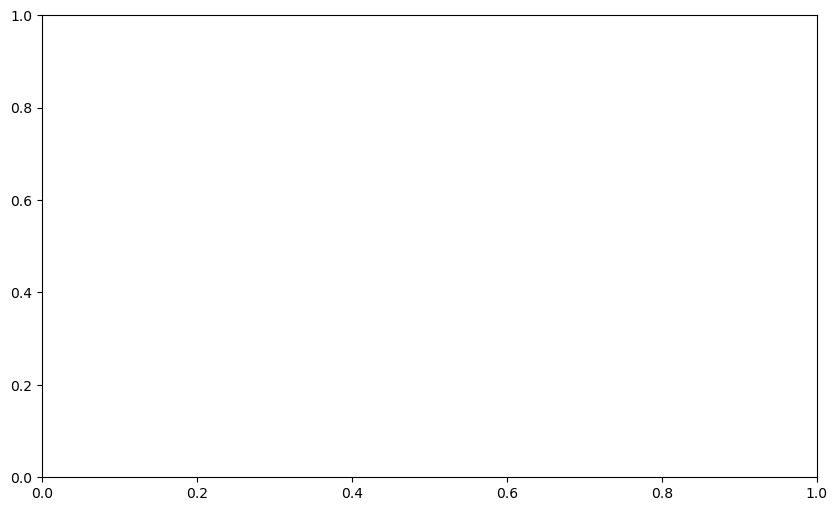

In [140]:
from sklearn.inspection import PartialDependenceDisplay

# Create a figure with a single axis
fig, ax = plt.subplots(figsize=(10, 6))

# Generate the partial dependence plot for one feature
PartialDependenceDisplay.from_estimator(
    KNN,
    X_train_reg,
    features=['Blaine (m2/kg)'],
    kind='average',
    grid_resolution=100,
    ax=ax
)

# --- Increase font sizes ---
ax.set_xlabel('Blaine fineness (m²/kg)', fontsize=16)   # was 12
ax.set_ylabel('Partial dependence (MPa)', fontsize=16)  # was 12
ax.set_title('Partial Dependence of 28‑day Strength on Blaine Fineness', fontsize=16)  # was 14
ax.tick_params(axis='both', labelsize=16)               # tick labels (numbers) larger
ax.grid(alpha=0.3)

# Save the figure as SVG
fig.savefig('pdp_blaine.svg', format='svg', bbox_inches='tight')
plt.show()

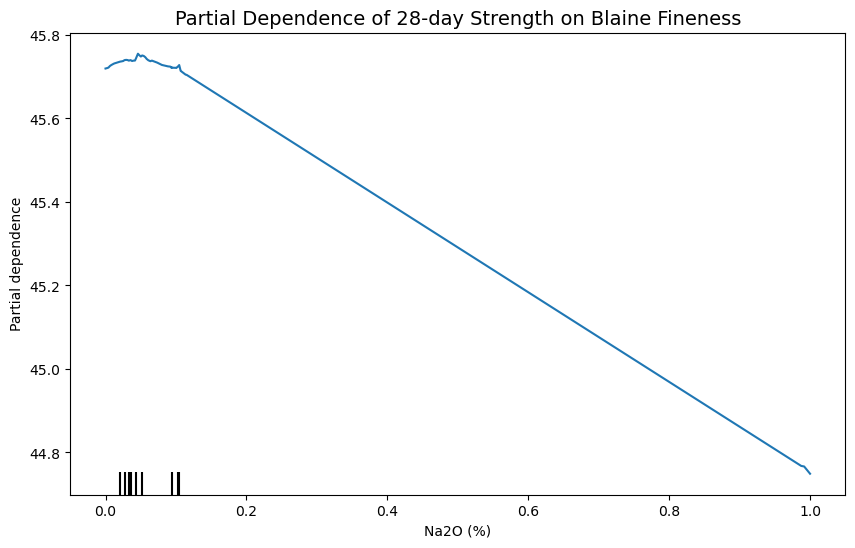

In [97]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Create a figure with a single axis
fig, ax = plt.subplots(figsize=(10, 6))

# Generate the partial dependence plot for one feature
PartialDependenceDisplay.from_estimator(
    KNN,                         # your trained KNN model
    X_train_reg,                       # training features (DataFrame or array)
    features=['Na2O (%)'], # single feature – adjust name if needed
    kind='average',              # shows average prediction
    grid_resolution=100,          # smoothness of the curve
    ax=ax                        # use the created axis
)

# Add labels and title (optional)
ax.set_xlabel('Blaine fineness (m²/kg)', fontsize=12)
ax.set_ylabel('Partial dependence (MPa)', fontsize=12)
ax.set_title('Partial Dependence of 28‑day Strength on Blaine Fineness', fontsize=14)
ax.grid(alpha=0.3)

# Save the figure as SVG (vector format, publication‑ready)
fig.savefig('pdp_na.svg', format='svg', bbox_inches='tight')

# Display the plot (optional, can be commented out when saving)
plt.show()